In [60]:
import os
import sys
sys.path.append(os.path.abspath('../scripts'))
fig_path      = '../figures/'
data_path     = '../data/'

In [61]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from proj_utils import *
from mapping_utils import *

In [62]:
def moving_corr(nao_f, gsi_f, lag_gs = 7, chunk_sz = 48):
    corrs_ = []
    uci_ = []; lci_ = [];
    for c in range(len(gsi_f)-(chunk_sz+lag_gs)):
        corrs_.append(np.corrcoef(nao_f[c:c+chunk_sz],gsi_f[lag_gs+c:lag_gs+c+chunk_sz])[0,1])
        lci_temp, uci_temp = get_cis(nao_f[c:c+chunk_sz],gsi_f[lag_gs+c:lag_gs+c+chunk_sz],0)
        lci_.append(lci_temp)
        uci_.append(uci_temp)
    return(corrs_, lci_, uci_)

In [72]:
gsi = xr.open_dataarray(data_path + 'gsi_two_layer_timeseries.nc')
nao = xr.open_dataarray(data_path + 'nao_era5_timeseries.nc')
eap = xr.open_dataarray(data_path + 'eap_era5_timeseries.nc')

nao = nao.sel(time = slice(gsi.time[0],gsi.time[-1]))
eap = eap.sel(time = slice(gsi.time[0],gsi.time[-1]))

In [73]:
# --- Filter the time series with Lanczos bandpass filter ---
gsi_f    = lanczos_bandpass(gsi, low_freq = 12*6, high_freq = 12*11, window = 12) 
gsi_f    = (gsi_f - gsi_f.mean(dim='time'))/gsi_f.std(dim = 'time')

nao_f    = lanczos_bandpass(nao, low_freq = 12*6, high_freq = 12*11, window = 12) 
nao_f    = (nao_f - nao_f.mean(dim='time'))/nao_f.std(dim = 'time')

eap_f    = lanczos_bandpass(eap, low_freq = 12*6, high_freq = 12*11, window = 12) 
eap_f    = (eap_f - eap_f.mean(dim='time'))/eap_f.std(dim = 'time')

In [74]:
# --- Drop nans from filtering ---
gsi_f = gsi_f.dropna(dim='time')
nao_f = nao_f.dropna(dim='time')
eap_f = eap_f.dropna(dim='time')

In [75]:
chunk_sz = 48; lag_gs = 7
corrs_nao, lci_nao, uci_nao = moving_corr(nao_f, gsi_f, lag_gs, chunk_sz)
corrs_eap, lci_eap, uci_eap = moving_corr(eap_f, gsi_f, lag_gs, chunk_sz)

In [76]:
nao_c = '#dc267f'
eap_c = '#fe6100'

In [77]:
ix_nao = []
for l in range(len(corrs_nao)):
    if corrs_nao[l] > uci_nao[l] or corrs_nao[l] < lci_nao[l]:
        ix_nao.append(l)
ix_nao = np.array(ix_nao)
corrs_nao = np.array(corrs_nao)

ix_eap = []
for l in range(len(corrs_eap)):
    if corrs_eap[l] > uci_eap[l] or corrs_eap[l] < lci_eap[l]:
        ix_eap.append(l)
ix_eap = np.array(ix_eap)
corrs_eap = np.array(corrs_eap)

In [45]:
corrs_eap_aste = corrs_eap
corrs_nao_aste = corrs_nao
gsi_f_aste = gsi_f
ix_nao_aste = ix_nao
ix_eap_aste = ix_eap

In [57]:
corrs_eap_ecco = corrs_eap
corrs_nao_ecco = corrs_nao
gsi_f_ecco = gsi_f
ix_nao_ecco = ix_nao
ix_eap_ecco = ix_eap

In [69]:
corrs_eap_alt = corrs_eap
corrs_nao_alt = corrs_nao
gsi_f_alt = gsi_f
ix_nao_alt = ix_nao
ix_eap_alt = ix_eap

In [78]:
corrs_eap_tl = corrs_eap
corrs_nao_tl = corrs_nao
gsi_f_tl = gsi_f
ix_nao_tl = ix_nao
ix_eap_tl = ix_eap

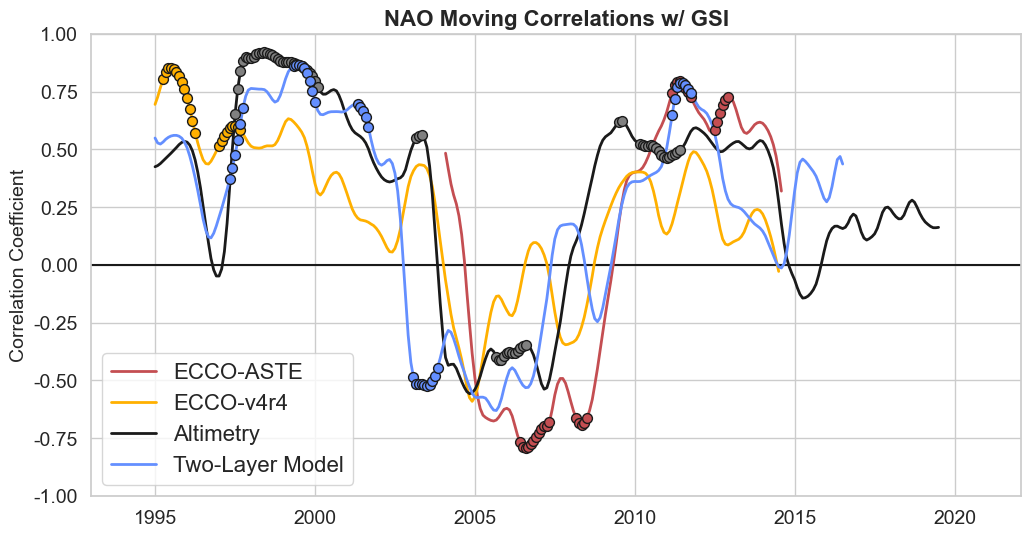

In [82]:
style = sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

av_per    = len(gsi_f)-len(corrs_nao)-lag_gs
plt.axhline(0, color='k', linewidth=1.5)

plt.plot(gsi_f_aste.time[av_per//2:-av_per//2-lag_gs],corrs_nao_aste,color = 'r', linewidth = 2, label = 'ECCO-ASTE')
plt.scatter(gsi_f_aste.time[av_per//2:-av_per//2-lag_gs][ix_nao_aste], corrs_nao_aste[ix_nao_aste], s=50, color = 'r',edgecolors='k',zorder = 10)

plt.plot(gsi_f_ecco.time[av_per//2:-av_per//2-lag_gs],corrs_nao_ecco,color = '#ffb000', linewidth = 2, label = 'ECCO-v4r4')
plt.scatter(gsi_f_ecco.time[av_per//2:-av_per//2-lag_gs][ix_nao_ecco], corrs_nao_ecco[ix_nao_ecco], s=50, color = '#ffb000',edgecolors='k',zorder = 10)

plt.plot(gsi_f_alt.time[av_per//2:-av_per//2-lag_gs],corrs_nao_alt,color = 'k', linewidth = 2, label = 'Altimetry')
plt.scatter(gsi_f_alt.time[av_per//2:-av_per//2-lag_gs][ix_nao_alt], corrs_nao_alt[ix_nao_alt], s=50, color = 'grey',edgecolors='k',zorder = 10)

plt.plot(gsi_f_tl.time[av_per//2:-av_per//2-lag_gs],corrs_nao_tl,color = '#648fff', linewidth = 2, label = 'Two-Layer Model')
plt.scatter(gsi_f_tl.time[av_per//2:-av_per//2-lag_gs][ix_nao_tl], corrs_nao_tl[ix_nao_tl], s=50, color = '#648fff',edgecolors='k',zorder = 10)

plt.xticks(gsi_f_alt.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
plt.yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
plt.xlim(gsi_f_alt.time[0],gsi_f_alt.time[-1])
plt.ylim(-1,1)
plt.ylabel('Correlation Coefficient',fontsize = 14)
plt.legend(fontsize=16)
plt.title('NAO Moving Correlations w/ GSI', fontsize = 16, fontweight='bold')
plt.savefig(fig_path + 'nao_lag_moving_average.png', format='png', bbox_inches="tight",dpi=500)

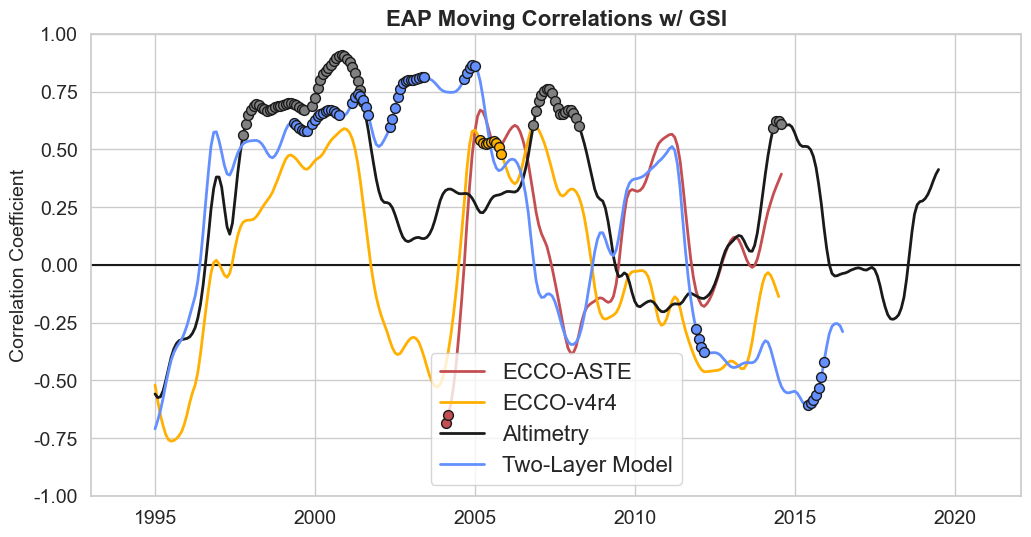

In [83]:
style = sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

av_per    = len(gsi_f)-len(corrs_nao)-lag_gs
plt.axhline(0, color='k', linewidth=1.5)

plt.plot(gsi_f_aste.time[av_per//2:-av_per//2-lag_gs],corrs_eap_aste,color = 'r', linewidth = 2, label = 'ECCO-ASTE')
plt.scatter(gsi_f_aste.time[av_per//2:-av_per//2-lag_gs][ix_eap_aste], corrs_eap_aste[ix_eap_aste], s=50, color = 'r',edgecolors='k',zorder = 10)

plt.plot(gsi_f_ecco.time[av_per//2:-av_per//2-lag_gs],corrs_eap_ecco,color = '#ffb000', linewidth = 2, label = 'ECCO-v4r4')
plt.scatter(gsi_f_ecco.time[av_per//2:-av_per//2-lag_gs][ix_eap_ecco], corrs_eap_ecco[ix_eap_ecco], s=50, color = '#ffb000',edgecolors='k',zorder = 10)

plt.plot(gsi_f_alt.time[av_per//2:-av_per//2-lag_gs],corrs_eap_alt,color = 'k', linewidth = 2, label = 'Altimetry')
plt.scatter(gsi_f_alt.time[av_per//2:-av_per//2-lag_gs][ix_eap_alt], corrs_eap_alt[ix_eap_alt], s=50, color = 'grey',edgecolors='k',zorder = 10)

plt.plot(gsi_f_tl.time[av_per//2:-av_per//2-lag_gs],corrs_eap_tl,color = '#648fff', linewidth = 2, label = 'Two-Layer Model')
plt.scatter(gsi_f_tl.time[av_per//2:-av_per//2-lag_gs][ix_eap_tl], corrs_eap_tl[ix_eap_tl], s=50, color = '#648fff',edgecolors='k',zorder = 10)

plt.xticks(gsi_f_alt.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
plt.yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
plt.xlim(gsi_f_alt.time[0],gsi_f_alt.time[-1])
plt.ylim(-1,1)
plt.ylabel('Correlation Coefficient',fontsize = 14)
plt.legend(fontsize=16)
plt.title('EAP Moving Correlations w/ GSI', fontsize = 16, fontweight='bold')
plt.savefig(fig_path + 'eap_lag_moving_average.png', format='png', bbox_inches="tight",dpi=500)

In [84]:
fig_path

'../figures/'